# Individual homework project 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import data
customers = pd.read_csv("customers.csv")
transactions = pd.read_csv("transactions.csv")
sessions = pd.read_csv("web_sessions.csv")
campaigns = pd.read_csv("marketing_campaigns.csv")

merged = transactions.merge(customers, on="customer_id")

### Specific questions

Q1. What is the average purchase value for customers from Spain?

In [3]:
# Insert code here
merged[merged["country"] == "Spain"]["purchase_value"].mean()

np.float64(75.63200247875355)

Q2. What is the minimum purchase value for customers from Germany?

In [4]:
merged[merged["country"] == "Germany"]["purchase_value"].min()

0.39

Q3. How much did males spend on buying products in the Sports category?

In [5]:
merged[(merged["gender"] == "Male") & (merged["product_category"] == "sports")]["purchase_value"].sum()

np.float64(191184.72)

Q4. What is the average age of female customers from Canada?

In [6]:
customers[(customers["gender"] == "Female") & (customers["country"] == "Canada")]["age"].mean()

np.float64(42.9168765743073)

Q5. How much does an average male customer from the UK spend?

In [7]:
merged[(merged["gender"] == "Male") & (merged["country"] == "UK")]["purchase_value"].mean()

np.float64(76.62530190677967)

Q6. What is the maximum purchase value for females in the Toys category?

In [8]:
merged[(merged["gender"] == "Female") & (merged["product_category"] == "toys")]["purchase_value"].max()

423.84

Q7. What is the average number of pages viewed for customers who made a purchase (converted)?

In [9]:
sessions[sessions["converted"] == 1]["pages_viewed"].mean()

np.float64(5.728619675345898)

Q8. What is the average time spent on the site for purchasing vs non-purchasing customers?

In [10]:
sessions.groupby("converted")["time_on_site"].mean()

,time_on_site
converted,
0,299.238547
1,311.194837


### Visualisation tasks

Q9. Plot purchasing value across years.

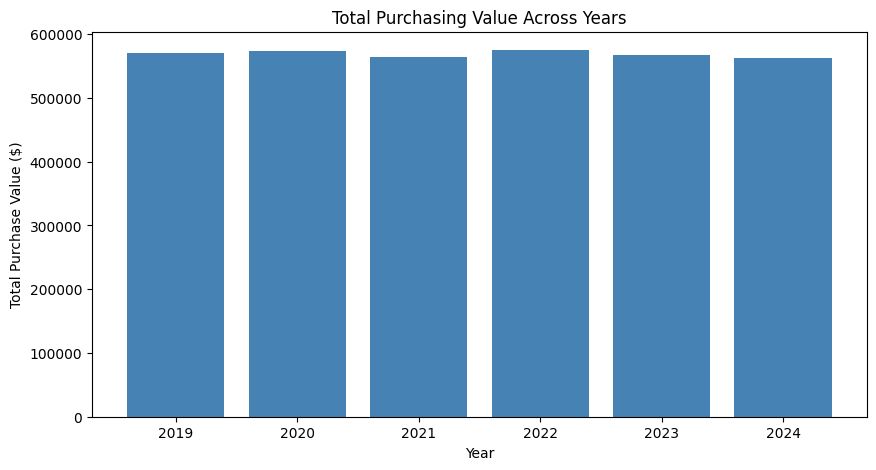

In [11]:
transactions["purchase_date"] = pd.to_datetime(transactions["purchase_date"])
transactions["year"] = transactions["purchase_date"].dt.year

yearly = transactions.groupby("year")["purchase_value"].sum()

plt.figure(figsize=(10,5))
plt.bar(yearly.index, yearly.values, color="steelblue")
plt.title("Total Purchasing Value Across Years")
plt.xlabel("Year")
plt.ylabel("Total Purchase Value ($)")
plt.show()

Q10. Plot purchasing value across product categories.

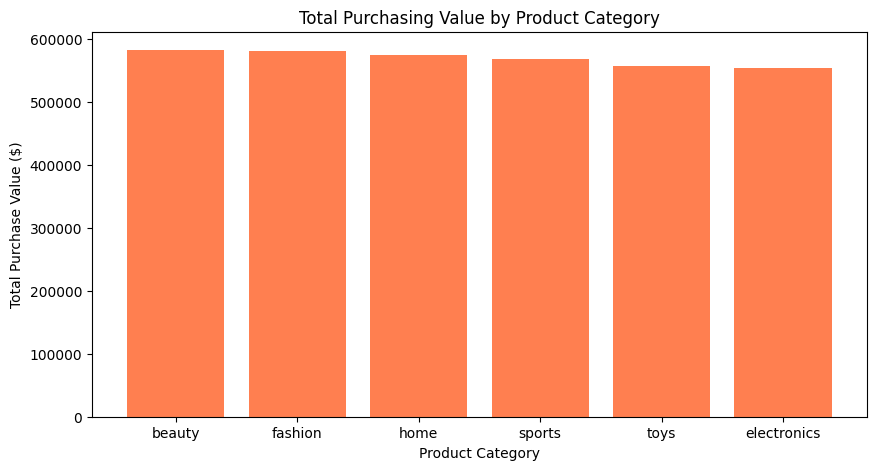

In [12]:
category_totals = transactions.groupby("product_category")["purchase_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(category_totals.index, category_totals.values, color="coral")
plt.title("Total Purchasing Value by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Value ($)")
plt.show()

### Free exercise

Explore the transactions dataset and:

- Create two visualisations of your choice
- Identify three patterns in the data
- Write five insights in plain English explaining what the data tells us

Your insights should focus on behaviour, spending patterns, or conversion

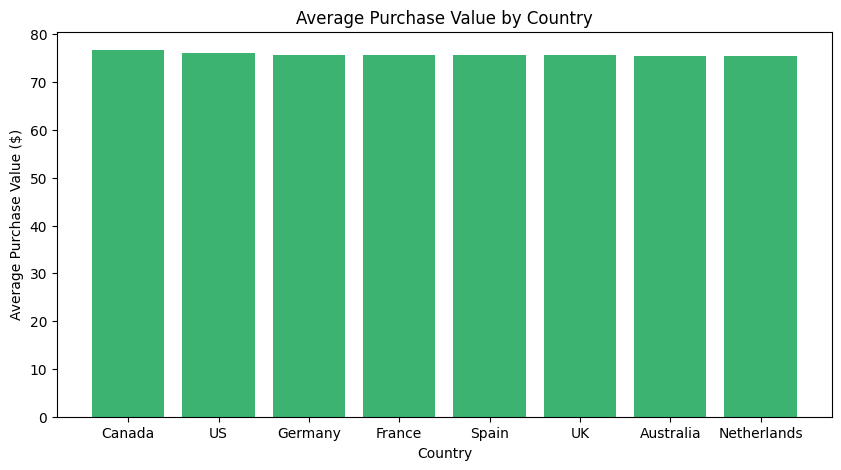

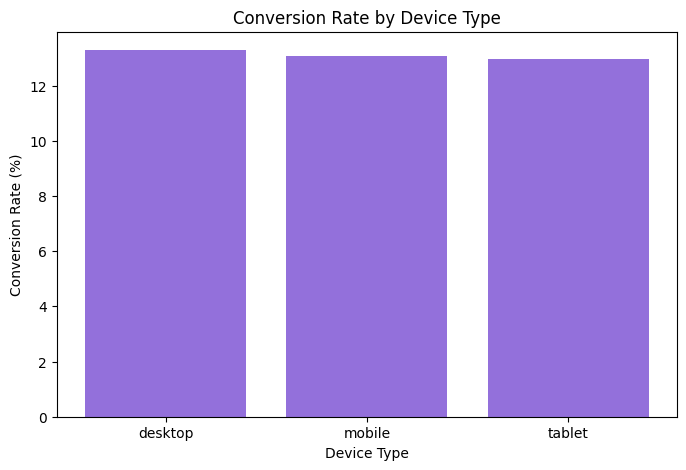

In [14]:
avg_by_country = merged.groupby("country")["purchase_value"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(avg_by_country.index, avg_by_country.values, color="mediumseagreen")
plt.title("Average Purchase Value by Country")
plt.xlabel("Country")
plt.ylabel("Average Purchase Value ($)")
plt.show()

conversion_by_device = sessions.groupby("device_type")["converted"].mean() * 100

plt.figure(figsize=(8,5))
plt.bar(conversion_by_device.index, conversion_by_device.values, color="mediumpurple")
plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate (%)")
plt.show()

3 Patterns I noticed:

Sales are very stable over time, every year from 2019 to 2024 brings in roughly the same amount of money, and every product category sells about the same too. Nothing stands out as unusually high or low.

Discounts lead to smaller purchases, when customers use a discount, they spend less 64 dollars on average compared to customers who pay full price 80 dollars. So discounts are not bringing in more money, they're actually reducing it.

Device type doesn't change buying behaviour much, whether someone is on a phone, tablet or computer, they convert at almost the same rate, around 12-13%.

